In [1]:
# Welcome back, I am excited to showcase this next part!
# This moves up a folder to access the juicy .py data
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt
import models as md
import backtest as bt
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok=True)
print("Imports Ok")

Imports Ok


In [3]:
airline_returns, macro_returns, prices = dt.load_data()
train = airline_returns[airline_returns.index <= dt.train_end]
covs = md.rolling_covariances(train, window=md.lookback, use_ledoit_wolf = True)
print(f"Covariance matrices: {len(covs)} dates")

Airlines: 7 tickers
Macro: 4 tickers
Dates: 2903 trading days
Range: 2015-01-05 -> 2026-07-16
Training: 2015-01-05 -> 2019-12-31
Validation: 2022-01-01 -> 2026-07-16
Covariance matrices: 1167 dates


In [4]:
systematic, residuals, evals_df, evecs_df, expl_df = md.compute_factor_model(train, covs, md.n_components)
print("Average explained variance (training):")
print(expl_df.mean().round(4))
print(f"Total: {expl_df.mean().sum():.1%}")

Average explained variance (training):
PC1    0.6094
PC2    0.1490
PC3    0.0762
dtype: float64
Total: 83.5%


In [5]:
zscore_window = 45
zscores = md.compute_rolling_zscore(residuals, window = zscore_window).dropna()

print(zscores.abs().describe().round(3))
print(f"\nEntry threshold: {bt.entry_threshold}")
print(f"% of values exceeding threshold: "
      f"{(zscores.abs() > bt.entry_threshold).mean().mean():.2%}")

            DAL       UAL       AAL       LUV       ALK      JBLU       CPA
count  1158.000  1158.000  1158.000  1158.000  1158.000  1158.000  1158.000
mean      0.748     0.717     0.744     0.701     0.734     0.727     0.738
std       0.641     0.709     0.642     0.702     0.663     0.731     0.811
min       0.003     0.000     0.000     0.000     0.002     0.001     0.002
25%       0.254     0.238     0.266     0.227     0.257     0.213     0.188
50%       0.575     0.536     0.590     0.503     0.547     0.504     0.485
75%       1.055     0.939     1.035     0.959     1.019     1.011     1.002
max       4.019     5.299     4.056     6.078     5.317     5.758     6.139

Entry threshold: 1.75
% of values exceeding threshold: 7.86%


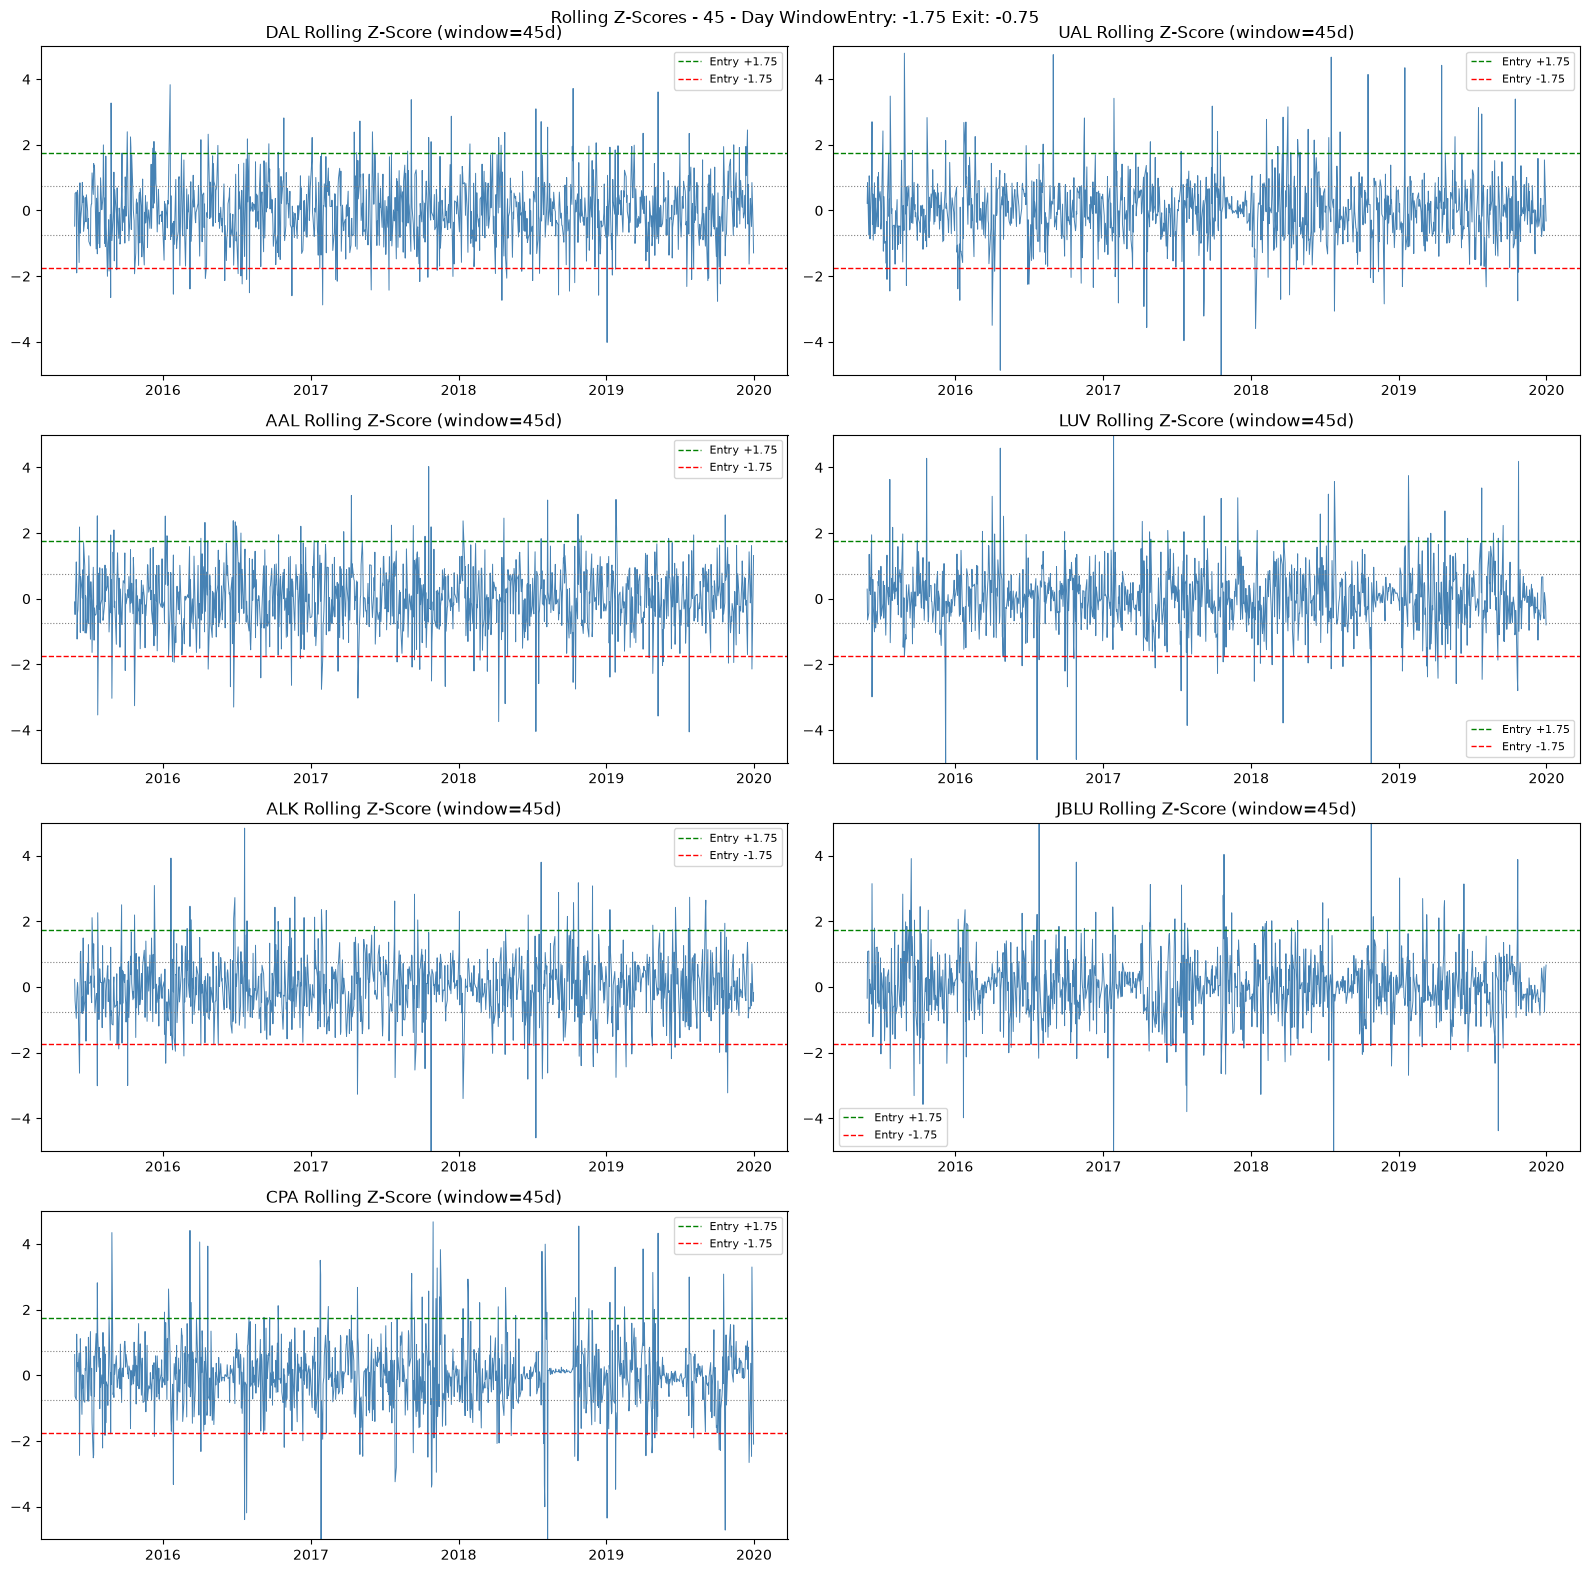

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(residuals.columns):
    z = zscores[col].dropna()
    axes[i].plot(z.index, z.values, linewidth=0.7, color='steelblue')
    axes[i].axhline( bt.entry_threshold, color='green', linestyle='--',
                     linewidth=1.0, label=f'Entry +{bt.entry_threshold}')
    axes[i].axhline(-bt.entry_threshold, color='red',   linestyle='--',
                     linewidth=1.0, label=f'Entry -{bt.entry_threshold}')
    axes[i].axhline( bt.exit_threshold, color='gray',  linestyle=':',
                     linewidth=0.8)
    axes[i].axhline(-bt.exit_threshold, color='gray',  linestyle=':',
                     linewidth=0.8)
    axes[i].set_title(f"{col} Rolling Z-Score (window={zscore_window}d)")
    axes[i].set_ylim(-5, 5)
    axes[i].legend(fontsize=8)
if len(residuals.columns) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle(f"Rolling Z-Scores - {zscore_window} - Day Window"
             f"Entry: -{bt.entry_threshold} Exit: -{bt.exit_threshold}",
             fontsize=12)
plt.tight_layout()
plt.show()

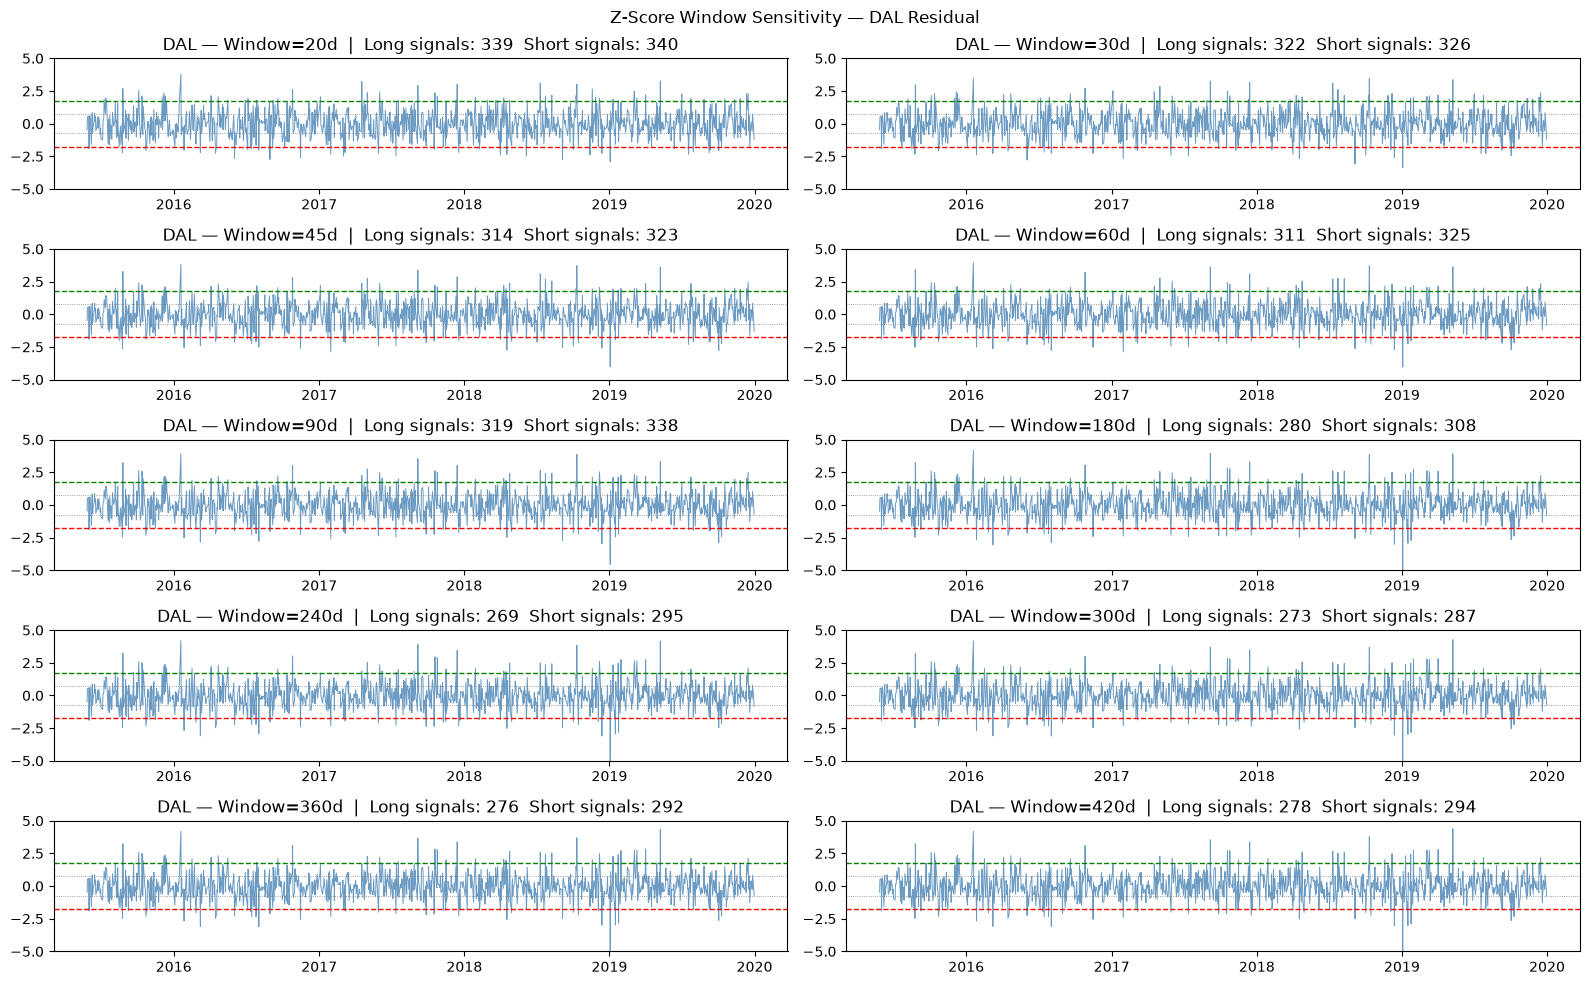

<function matplotlib.pyplot.show(close=None, block=None)>

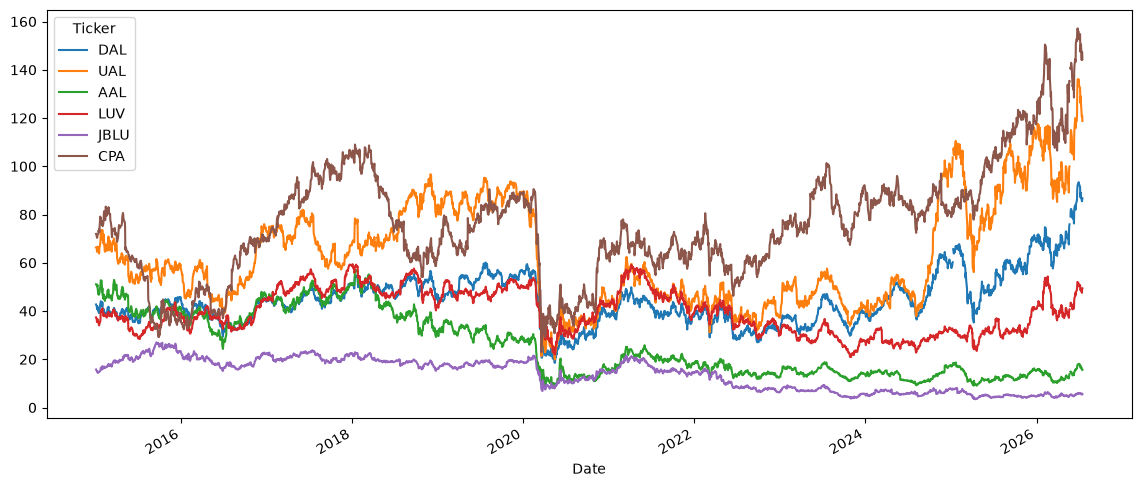

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(16, 10))
axes = axes.flatten()
windows = [20, 30, 45, 60, 90, 180, 240, 300, 360, 420]

for ax, w in zip(axes, windows):
    z = md.compute_rolling_zscore(residuals, window=w).dropna()

    # Count entry signals per ticker
    entries_long  = (z < -bt.entry_threshold).sum().sum()
    entries_short = (z > bt.entry_threshold).sum().sum()

    # Show DAL as representative
    ax.plot(z['DAL'].index, z['DAL'].values,
            linewidth=0.7, color='steelblue', alpha=0.8)
    ax.axhline( bt.entry_threshold, color='green', linestyle='--', linewidth=1.0)
    ax.axhline(-bt.entry_threshold, color='red', linestyle='--', linewidth=1.0)
    ax.axhline( bt.exit_threshold, color='gray', linestyle=':', linewidth=0.6)
    ax.axhline(-bt.exit_threshold, color='gray', linestyle=':', linewidth=0.6)
    ax.set_ylim(-5, 5)
    ax.set_title(f"DAL — Window={w}d  |  Long signals: {entries_long}  "
                 f"Short signals: {entries_short}")

plt.suptitle("Z-Score Window Sensitivity — DAL Residual", fontsize=12)
plt.tight_layout()
plt.show()
prices[["DAL","UAL","AAL","LUV","JBLU","CPA"]].plot(figsize=(14,6))
plt.show

In [8]:
# For diagnostics purposes only, this Sharpe is to determine the ultimate decision of zscores = 45 rolling 2015 - 2019 only 
train_air = airline_returns[airline_returns.index <= dt.train_end]
train_macro = macro_returns[macro_returns.index <= dt.train_end]
train_returns = airline_returns[airline_returns.index <= dt.train_end].copy()
train_macro_r = macro_returns[macro_returns.index <= dt.train_end].copy()
covs_train = md.rolling_covariances(train_air, window=md.lookback,
                                     use_ledoit_wolf=True)
_, resid_train, _, _, _ = md.compute_factor_model(
    train_air, covs_train, md.n_components)
conc_train = md.compute_pc1_concentration(covs_train)

print(f"{'Window':>8} {'Signals':>8} {'Sharpe':>8} {'Ann.Ret':>9} {'Ann.Vol':>9} {'Turnover':>10}")
print("─" * 58)

for w in [20, 30, 45, 60, 90, 180, 240, 300, 360, 420]:
    z = md.compute_rolling_zscore(resid_train, window=w).dropna()
    s = bt.generate_signals(z, top_n=bt.top_n, min_hold=bt.min_hold_days, momentum = False)
    p = bt.construct_portfolio(s, zscores=z, residuals=resid_train)
    ps = bt.apply_continuous_concentration_scaling(p, conc_train)
    net, trades = bt.compute_portfolio_returns(ps, train_air)
    net = net.dropna()

    if len(net) < 30:
        print(f"{w:>8}d  insufficient data")
        continue

    ar = net.mean() * 252
    av = net.std() * (252**0.5)
    sr = ar / av if av > 0 else float('nan')
    to = trades['turnover'].mean() * 252
    n_sig = (s != 0).any(axis=1).sum()

    print(f"{w:>7}d  {n_sig:>8}  {sr:>8.3f}  {ar:>9.2%}  {av:>9.2%}  {to:>10.2f}")

  Window  Signals   Sharpe   Ann.Ret   Ann.Vol   Turnover
──────────────────────────────────────────────────────────
     20d       910    -1.419     -8.44%      5.95%       20.72
     30d       905    -1.553     -9.41%      6.06%       19.68
     45d       865    -1.378     -8.24%      5.98%       17.74
     60d       892    -1.174     -7.23%      6.16%       17.60
     90d       898    -1.028     -6.17%      6.00%       18.09
    180d       825    -1.036     -6.21%      5.99%       16.61
    240d       833    -0.864     -4.91%      5.68%       15.90
    300d       818    -1.004     -5.84%      5.82%       15.46
    360d       828    -0.996     -5.87%      5.90%       16.06
    420d       837    -0.938     -5.51%      5.88%       16.04


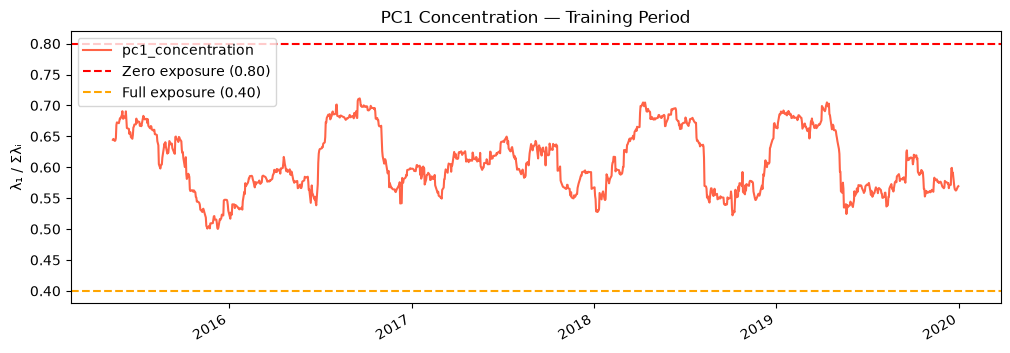

Days above 0.80 (crisis): 0
Days above 0.65: 304


In [9]:
pc1 = md.compute_pc1_concentration(covs)
pc1.plot(figsize=(12,4), color='tomato',
         title="PC1 Concentration — Training Period")
plt.axhline(bt.conc_zero, color='red', linestyle='--', label='Zero exposure (0.80)')
plt.axhline(bt.conc_full, color='orange', linestyle='--', label='Full exposure (0.40)')
plt.ylabel("λ₁ / Σλᵢ")
plt.legend(); plt.show()
print(f"Days above 0.80 (crisis): {(pc1>0.80).sum()}")
print(f"Days above 0.65: {(pc1>0.65).sum()}")

In [10]:
lag_df = md.compute_brent_leadlag(residuals, macro_returns, max_lag=21)


=== Brent Lead-Lag Correlations ===
(negative = Brent rise predicts airline underperformance)
        DAL     UAL     AAL     LUV     ALK    JBLU     CPA
lag                                                        
1   -0.0409  0.0512 -0.0368  0.0250 -0.0420  0.0329  0.0423
2   -0.0232 -0.0230 -0.0108  0.0625 -0.0088  0.0112 -0.0201
3    0.0354  0.0025  0.0152 -0.0100 -0.0475  0.0249 -0.0072
4   -0.0074  0.0019  0.0170 -0.0036  0.0680 -0.0914 -0.0071
5   -0.0731  0.0264 -0.0132  0.0217  0.0190  0.0228 -0.0248
6   -0.0253  0.0002 -0.0094  0.0331  0.0106 -0.0155  0.0249
7   -0.0522 -0.0289  0.0612 -0.0245 -0.0366  0.0511  0.0198
8    0.0116  0.0165  0.0203  0.0030  0.0054 -0.0555 -0.0189
9   -0.0514 -0.0154  0.0106 -0.0019  0.0833 -0.0153  0.0154
10   0.0485 -0.0230  0.0034  0.0748 -0.0706 -0.0310  0.0001
11  -0.0002 -0.0071 -0.0147  0.0057  0.0130 -0.0054  0.0064
12   0.0782 -0.0153 -0.0356 -0.0141 -0.0281  0.0303 -0.0026
13   0.0466  0.0044 -0.0140 -0.0059 -0.0050 -0.0257  0.0165
14   

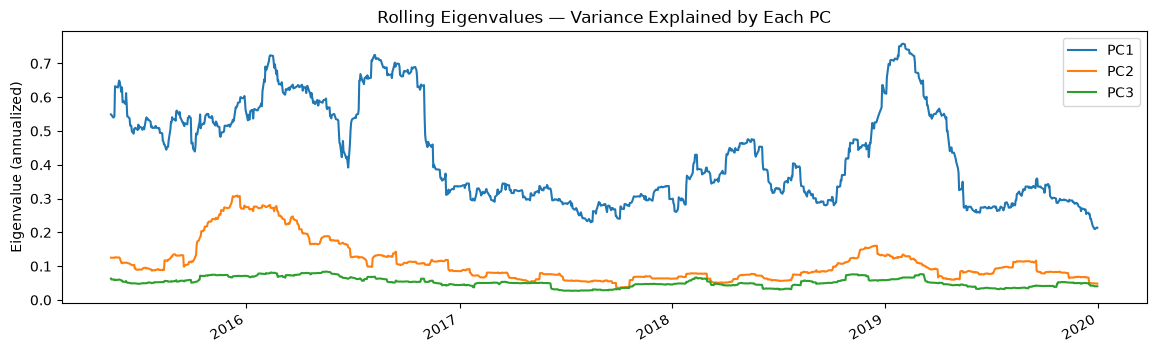

In [11]:
evals_df.plot(figsize=(14,4),title="Rolling Eigenvalues — Variance Explained by Each PC")
plt.ylabel("Eigenvalue (annualized)")
plt.show()

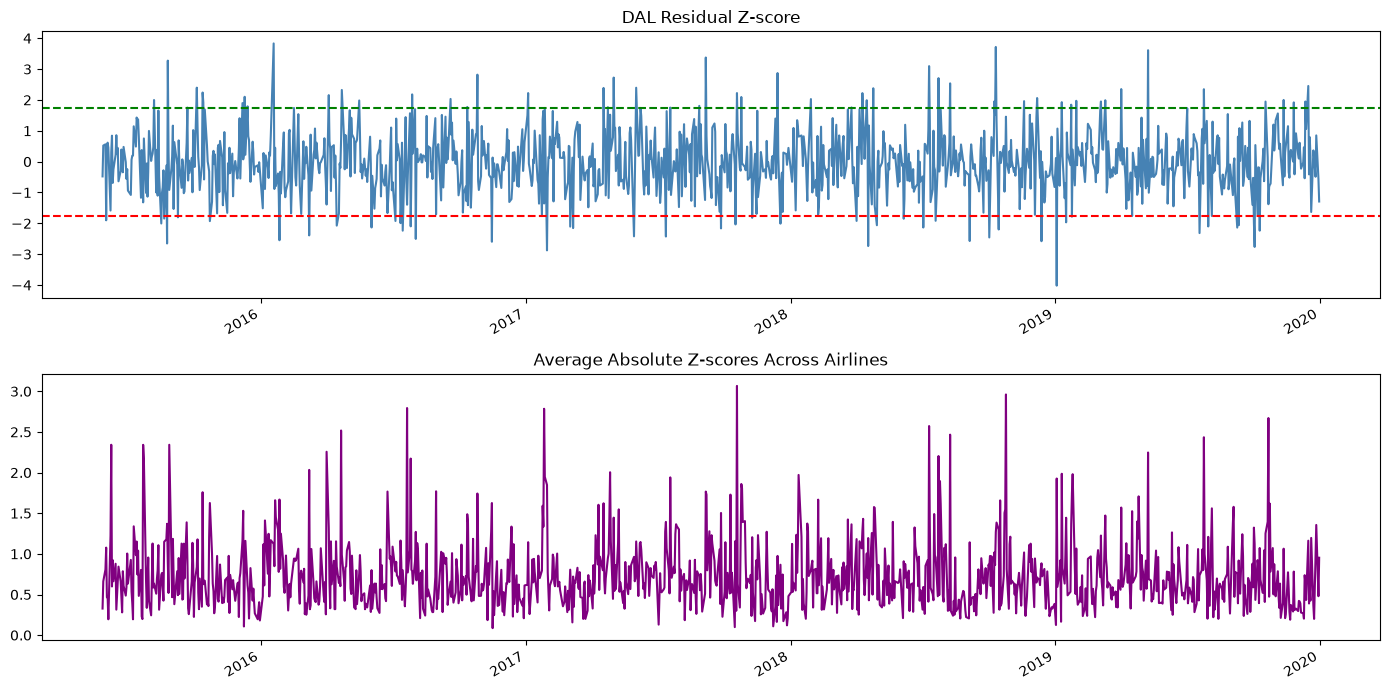


            DAL       UAL       AAL       LUV       ALK      JBLU       CPA
count  1158.000  1158.000  1158.000  1158.000  1158.000  1158.000  1158.000
mean     -0.002    -0.008     0.007     0.008    -0.012     0.002    -0.008
std       0.985     1.009     0.983     0.993     0.989     1.031     1.097
min      -4.019    -5.299    -4.056    -6.078    -5.317    -5.758    -6.139
25%      -0.585    -0.566    -0.554    -0.487    -0.572    -0.526    -0.512
50%      -0.020    -0.009     0.002     0.005     0.011    -0.012     0.025
75%       0.561     0.529     0.637     0.518     0.531     0.473     0.453
max       3.831     4.791     4.025     5.256     4.838     5.448     4.673


In [12]:
fig, axes = plt.subplots(2,1,figsize=(14,7))

zscores["DAL"].plot(ax=axes[0], color="steelblue")
axes[0].axhline(bt.entry_threshold,color="green",linestyle="--")
axes[0].axhline(-bt.entry_threshold,color="red",linestyle="--")
axes[0].set_title("DAL Residual Z-score")
zscores.abs().mean(axis=1).plot(ax=axes[1], color="purple")
axes[1].set_title("Average Absolute Z-scores Across Airlines")
plt.tight_layout()
plt.show()
print()
print(zscores.describe().round(3))